# Training Plots

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
plt.rcParams.update({
    "text.usetex": True,          
    "font.family": "serif",     
    "font.serif": ["Computer Modern"]
})
import pandas as pd
import seaborn as sns

In [ ]:
# extract values
def extract_metric(metric_name):
    if metric_name not in event_acc.Tags()["scalars"]:
        print(f"{metric_name} not found!")
        return None, None
    
    events = event_acc.Scalars(metric_name)
    epochs = np.arange(len(events))  
    values = [e.value for e in events]
    return epochs, np.array(values)


def plot_loss(log_dir):

    event_acc = EventAccumulator(log_dir)
    event_acc.Reload()

    train_events = event_acc.Scalars("train_avg_loss")
    val_events = event_acc.Scalars("val_avg_loss")

    train_steps = np.array([e.step for e in train_events])
    train_values = np.array([e.value for e in train_events])

    val_steps = np.array([e.step for e in val_events])
    val_values = np.array([e.value for e in val_events])

    # map each train step to closest validation step (epoch)
    train_epoch_indices = np.searchsorted(val_steps, train_steps, side="right") - 1
    train_epoch_indices = np.clip(train_epoch_indices, 0, len(val_steps)-1)

    # average train loss per epoch
    num_epochs = len(val_values)
    train_loss_epoch = [
        train_values[train_epoch_indices == i].mean()
        for i in range(num_epochs)
    ]

    epochs = np.arange(num_epochs)

    plt.figure()
    plt.plot(epochs[0:251], train_loss_epoch[0:251])
    plt.plot(epochs[0:251], val_values[0:251])
    plt.ylim(0, 0.1)
    plt.xlabel(r"\textbf{Epoch}", fontsize=28)
    plt.ylabel(r"\textbf{Loss}", fontsize=28)
    #plt.title("Train vs Validation Loss", fontsize=16)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.legend([r"\textbf{Train Loss}", r"\textbf{Validation Loss}"], fontsize=18)
    plt.show()

    return event_acc

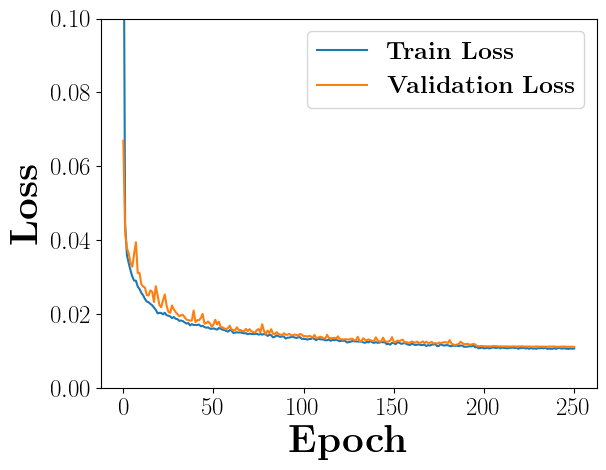

In [18]:
_ = plot_loss("../../temp/version_110")

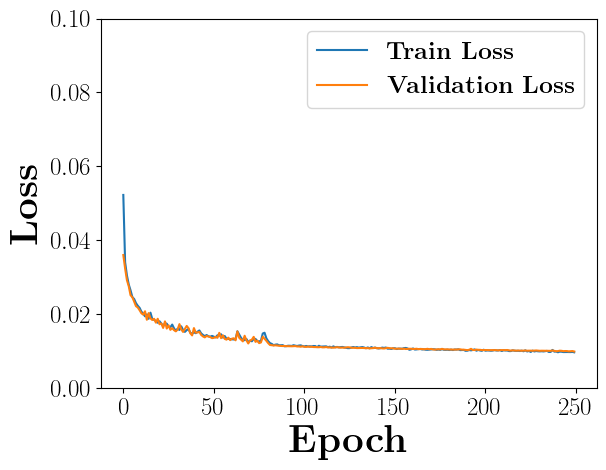

In [16]:
_ = plot_loss("../../temp/version_106")